<a href="https://colab.research.google.com/github/brittanybee-alt/Capstone-Project-Two/blob/main/Capstone_Two_Data_Wrangling_%5BBrittany_Barrion%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Where You Grow Up Matters: Predicting Adult Income for Low-Income Children in the DC Region

Which neighborhood characteristics best predict adult income for children raised in low-income families in the DC metro area?

In [51]:
import pandas as pd

outcomes = pd.read_csv("/content/data/raw/shown_tract_kfr_rP_gP_p25.csv")
predictors = pd.read_csv("/content/data/raw/shown_tract_allCharacteristics.csv")

print(outcomes.shape, predictors.shape)

# Join on tract ID; 'Name' is in both files, so drop it from one side
df = outcomes.merge(predictors.drop(columns="Name"), on="tract", how="inner")
print(df.shape)
df.head()

(410, 3) (412, 15)
(410, 16)


,tract,Name,Household_Income_at_Age_35_rP_gP_p25,Median_Rent_2012-16,Job_Growth_Rate_from_2004_to_2013,Median_Hhold._Income_of_Residents_in_2012-16,Median_Hhold._Income_of_Residents_in_1990,Poverty_Rate_in_2012-16,Fraction_College_Graduates_in_2012-16,Fraction_Non-White_in_2010,Foreign-Born_Share_in_2012-16,Fraction_Single_Parents_in_2012-16,Population_Density_in_2010,Density_of_Jobs_in_2013,Fraction_with_Short_Work_Commutes_in_2012-16,Census_Response_Rate_Social_Capital_Proxy
0,51013100400,"Arlington, VA",68322.0,3501.0,-0.0293,202909.0,162342,0.0286,0.8635,0.1214,0.1138,0.0941,2358.0,120.5,0.2106,91.2
1,51013101601,"North Highland, Arlington, VA",65785.0,1982.0,-0.0358,119122.0,74114,0.1455,0.8462,0.2323,0.1876,0.2963,4899.0,2037.0,0.1230,79.5
2,51510200702,"Eisenhower East, Alexandria, VA",64583.0,2186.0,0.0337,110481.0,64247,0.0222,0.8253,0.3072,0.1373,0.4101,8445.0,13782.0,0.1798,82.1
3,24031705300,"Chevy Chase, MD",63907.0,3375.0,0.0176,246886.0,232485,0.0183,0.8910,0.0675,0.1335,0.0656,4656.0,1619.0,0.1481,91.8
4,51510202001,"Old Town, Alexandria, VA",62664.0,2750.0,0.0154,174054.0,140144,0.0115,0.8876,0.0729,0.0944,0.1842,11405.0,4411.0,0.2172,86.3


In [52]:
import os

os.makedirs(os.path.dirname("data/processed/merged_data.csv"), exist_ok=True)
df.to_csv("data/processed/merged_data.csv", index=False)

In [53]:
import os, glob, shutil

os.makedirs("data/raw", exist_ok=True)

# List of files to move
files_to_move = [
    "shown_tract_kfr_rP_gP_p25.csv",
    "shown_tract_allCharacteristics.csv"
]

for filename in files_to_move:
    source_path = filename
    destination_path = os.path.join("data", "raw", filename)

    if os.path.exists(source_path):
        # If the file exists in the destination, remove it before moving to prevent error
        if os.path.exists(destination_path):
            os.remove(destination_path)
            print(f"Removed existing {destination_path} before moving.")
        shutil.move(source_path, "data/raw/")
        print(f"Moved {source_path} to data/raw/")
    else:
        print(f"{source_path} not found in current directory. Assuming it has been moved already.")

glob.glob("data/raw/*.csv")

shown_tract_kfr_rP_gP_p25.csv not found in current directory. Assuming it has been moved already.
shown_tract_allCharacteristics.csv not found in current directory. Assuming it has been moved already.


['data/raw/shown_tract_allCharacteristics.csv',
 'data/raw/shown_tract_kfr_rP_gP_p25.csv']

In [54]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 410 entries, 0 to 409
Data columns (total 16 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   tract                                         410 non-null    int64  
 1   Name                                          410 non-null    object 
 2   Household_Income_at_Age_35_rP_gP_p25          406 non-null    float64
 3   Median_Rent_2012-16                           406 non-null    float64
 4   Job_Growth_Rate_from_2004_to_2013             231 non-null    float64
 5   Median_Hhold._Income_of_Residents_in_2012-16  407 non-null    float64
 6   Median_Hhold._Income_of_Residents_in_1990     410 non-null    int64  
 7   Poverty_Rate_in_2012-16                       410 non-null    float64
 8   Fraction_College_Graduates_in_2012-16         410 non-null    float64
 9   Fraction_Non-White_in_2010                    410 non-null    flo

In [55]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tract,410.0,2.476926e+10,1.577187e+10,1.100100e+10,1.100101e+10,2.403170e+10,2.403381e+10,5.151020e+10
Household_Income_at_Age_35_rP_gP_p25,406.0,3.255549e+04,8.819113e+03,1.951500e+04,2.557225e+04,3.142800e+04,3.765150e+04,6.832200e+04
Median_Rent_2012-16,406.0,1.566783e+03,5.540436e+02,3.680000e+02,1.160000e+03,1.474500e+03,1.841750e+03,3.501000e+03
Job_Growth_Rate_from_2004_to_2013,231.0,7.543290e-03,7.508954e-02,-2.389000e-01,-2.735000e-02,2.600000e-03,3.350000e-02,3.579000e-01
Median_Hhold._Income_of_Residents_in_2012-16,407.0,8.633488e+04,4.512196e+04,1.450900e+04,5.378450e+04,7.683900e+04,1.071755e+05,2.468860e+05
Median_Hhold._Income_of_Residents_in_1990,410.0,7.179173e+04,3.277303e+04,1.117600e+04,5.371125e+04,6.642850e+04,8.293100e+04,2.721050e+05
Poverty_Rate_in_2012-16,410.0,1.408300e-01,1.160049e-01,0.000000e+00,5.970000e-02,1.114500e-01,1.830250e-01,6.952000e-01
Fraction_College_Graduates_in_2012-16,410.0,5.096002e-01,2.856820e-01,1.490000e-02,2.203000e-01,5.114500e-01,7.979750e-01,1.000000e+00
Fraction_Non-White_in_2010,410.0,6.335098e-01,3.106680e-01,6.750000e-02,3.202750e-01,6.706000e-01,9.513750e-01,9.975000e-01
Foreign-Born_Share_in_2012-16,410.0,1.965120e-01,1.499706e-01,0.000000e+00,8.115000e-02,1.610500e-01,2.665250e-01,7.112000e-01


In [56]:
numeric = df.select_dtypes("number").drop(columns="tract")
pd.DataFrame({"median": numeric.median(), "mode": numeric.mode().iloc[0]})

,median,mode
Household_Income_at_Age_35_rP_gP_p25,31428.00000,22787.0000
Median_Rent_2012-16,1474.50000,3501.0000
Job_Growth_Rate_from_2004_to_2013,0.00260,-0.0005
Median_Hhold._Income_of_Residents_in_2012-16,76839.00000,246886.0000
Median_Hhold._Income_of_Residents_in_1990,66428.50000,54553.0000
Poverty_Rate_in_2012-16,0.11145,0.0098
Fraction_College_Graduates_in_2012-16,0.51145,0.8707
Fraction_Non-White_in_2010,0.67060,0.1258
Foreign-Born_Share_in_2012-16,0.16105,0.0000
Fraction_Single_Parents_in_2012-16,0.37170,0.0000


In [57]:
uniq = pd.DataFrame({
    "n_unique": df.nunique(),
    "pct_unique": (df.nunique() / len(df) * 100).round(1)
})
uniq

,n_unique,pct_unique
tract,410,100.0
Name,133,32.4
Household_Income_at_Age_35_rP_gP_p25,403,98.3
Median_Rent_2012-16,355,86.6
Job_Growth_Rate_from_2004_to_2013,219,53.4
Median_Hhold._Income_of_Residents_in_2012-16,404,98.5
Median_Hhold._Income_of_Residents_in_1990,369,90.0
Poverty_Rate_in_2012-16,382,93.2
Fraction_College_Graduates_in_2012-16,394,96.1
Fraction_Non-White_in_2010,390,95.1


In [58]:
pd.DataFrame({"min": numeric.min(), "max": numeric.max()})

,min,max
Household_Income_at_Age_35_rP_gP_p25,19515.0000,68322.0000
Median_Rent_2012-16,368.0000,3501.0000
Job_Growth_Rate_from_2004_to_2013,-0.2389,0.3579
Median_Hhold._Income_of_Residents_in_2012-16,14509.0000,246886.0000
Median_Hhold._Income_of_Residents_in_1990,11176.0000,272105.0000
Poverty_Rate_in_2012-16,0.0000,0.6952
Fraction_College_Graduates_in_2012-16,0.0149,1.0000
Fraction_Non-White_in_2010,0.0675,0.9975
Foreign-Born_Share_in_2012-16,0.0000,0.7112
Fraction_Single_Parents_in_2012-16,0.0000,1.0000


In [59]:
df["state"] = df["Name"].str.extract(r",\s*([^,]+)$")[0]
df["state"].value_counts()

,count
state,
DC,179
MD,134
VA,97


In [60]:
missing = pd.DataFrame({
    "n_missing": df.isnull().sum(),
    "pct_missing": (df.isnull().mean() * 100).round(1)
})
missing[missing.n_missing > 0].sort_values("n_missing", ascending=False)

,n_missing,pct_missing
Job_Growth_Rate_from_2004_to_2013,179,43.7
Household_Income_at_Age_35_rP_gP_p25,4,1.0
Median_Rent_2012-16,4,1.0
Median_Hhold._Income_of_Residents_in_2012-16,3,0.7
Fraction_Single_Parents_in_2012-16,3,0.7


In [61]:
df["jobgrowth_missing"] = df["Job_Growth_Rate_from_2004_to_2013"].isnull()

# Are the missing tracts different (e.g., fewer jobs)?
df.groupby("jobgrowth_missing")["Density_of_Jobs_in_2013"].median()

# Is it concentrated in one state?
df["state"] = df["Name"].str.extract(r",\s*([^,]+)$")[0]
df.groupby("state")["jobgrowth_missing"].mean().round(2)

,jobgrowth_missing
state,
DC,1.0
MD,0.0
VA,0.0


In [62]:
small = ["Median_Rent_2012-16",
         "Median_Hhold._Income_of_Residents_in_2012-16",
         "Fraction_Single_Parents_in_2012-16"]
df[df[small].isnull().any(axis=1)][["Name"] + small]

,Name,Median_Rent_2012-16,Median_Hhold._Income_of_Residents_in_2012-16,Fraction_Single_Parents_in_2012-16
101,"Northwest Washington, Washington, DC",1712.0,31732.0,NaN
243,"Northwest Washington, Washington, DC",NaN,66629.0,0.3617
407,"Northwest Washington, Washington, DC",NaN,NaN,NaN
408,"Southeast Washington, Washington, DC",NaN,NaN,1.0000
409,"Georgetown, Washington, DC",NaN,NaN,NaN


In [63]:
outcome = "Household_Income_at_Age_35_rP_gP_p25"
small = ["Median_Rent_2012-16",
         "Median_Hhold._Income_of_Residents_in_2012-16",
         "Fraction_Single_Parents_in_2012-16"]

# 1. Drop tracts with no outcome (can't predict what we don't have)
df_clean = df.dropna(subset=[outcome]).copy()

# 2. Drop job growth (missing for all of DC) and the helper column
df_clean = df_clean.drop(columns=["Job_Growth_Rate_from_2004_to_2013",
                                  "jobgrowth_missing"])

# 3. Drop tracts missing 2+ of the three small-gap columns
too_incomplete = df_clean[small].isnull().sum(axis=1) >= 2
df_clean = df_clean[~too_incomplete].copy()

# 4. Fill remaining single gaps with the column median
for col in small:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(df_clean.shape)
print(df_clean.isnull().sum().sum())   # should be 0

(406, 16)
0


A note for your write-up: because job growth is gone, your model can't use it as a predictor. Mention that as a limitation.

55770.375 9


<Axes: >

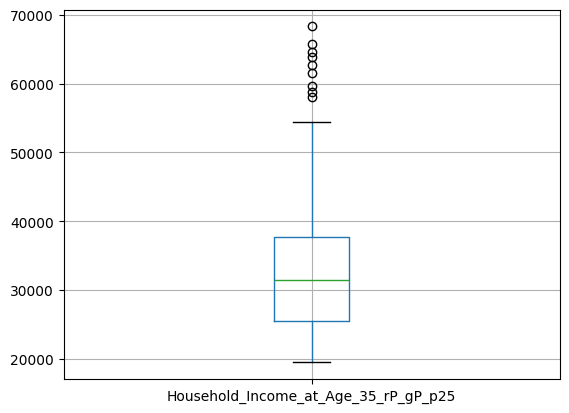

In [64]:
q1, q3 = df_clean[outcome].quantile([0.25, 0.75])
upper = q3 + 1.5 * (q3 - q1)
print(upper, (df_clean[outcome] > upper).sum())
df_clean.boxplot(column=outcome)

In [65]:
df_clean["tract"] = df_clean["tract"].astype(str)

In [66]:
df_clean.to_csv("data/processed/cleaned_data.csv", index=False)